In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

da = pd.read_excel('../../utaut2_dataset/utaut2_subsample.xlsx')

construct_names = {
    'PU': 'Воспринимаемая полезность',
    'PEOU': 'Лёгкость использования',
    'SI': 'Социальное влияние',
    'FC': 'Поддерживающие условия',
    'HM': 'Гедоническая мотивация',
    'PV': 'Ценность цены',
    'HAB': 'Привычка',
    'BI': 'Поведенческое намерение'
}

constructs = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB', 'BI']
predictors = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB']

# Пункты конструктов (нужны для Cronbach alpha)
df_full = pd.read_excel('../../utaut2_dataset/new_result.xlsx')
cols = df_full.columns.tolist()
construct_items = {
    'PU':   cols[13:16],
    'PEOU': cols[16:19],
    'SI':   cols[19:22],
    'FC':   cols[22:25],
    'HM':   cols[25:28],
    'PV':   cols[28:31],
    'HAB':  cols[31:34],
    'BI':   cols[34:37],
}

print(f'Аналитическая подвыборка UTAUT2: {len(da)}')

Аналитическая подвыборка UTAUT2: 164


In [2]:
exp_col = 'Have you ever used online fitness or wellness services?'

groups = da.groupby(exp_col)['BI']
group_values = [g.values for _, g in groups]
H_exp, p_exp = stats.kruskal(*group_values)

print('BI по опыту использования онлайн-фитнеса:\n')
for name, g in groups:
    print(f'{name}: M = {g.mean():.2f}, SD = {g.std():.2f}, n = {len(g)}')

print(f'\nKruskal-Wallis: H = {H_exp:.2f}, p = {p_exp:.4f}')


BI по опыту использования онлайн-фитнеса:

No: M = 3.47, SD = 0.65, n = 67
Yes, currently use them: M = 3.92, SD = 0.65, n = 48
Yes, tried in the past but no longer use them: M = 3.82, SD = 0.67, n = 49

Kruskal-Wallis: H = 14.31, p = 0.0008


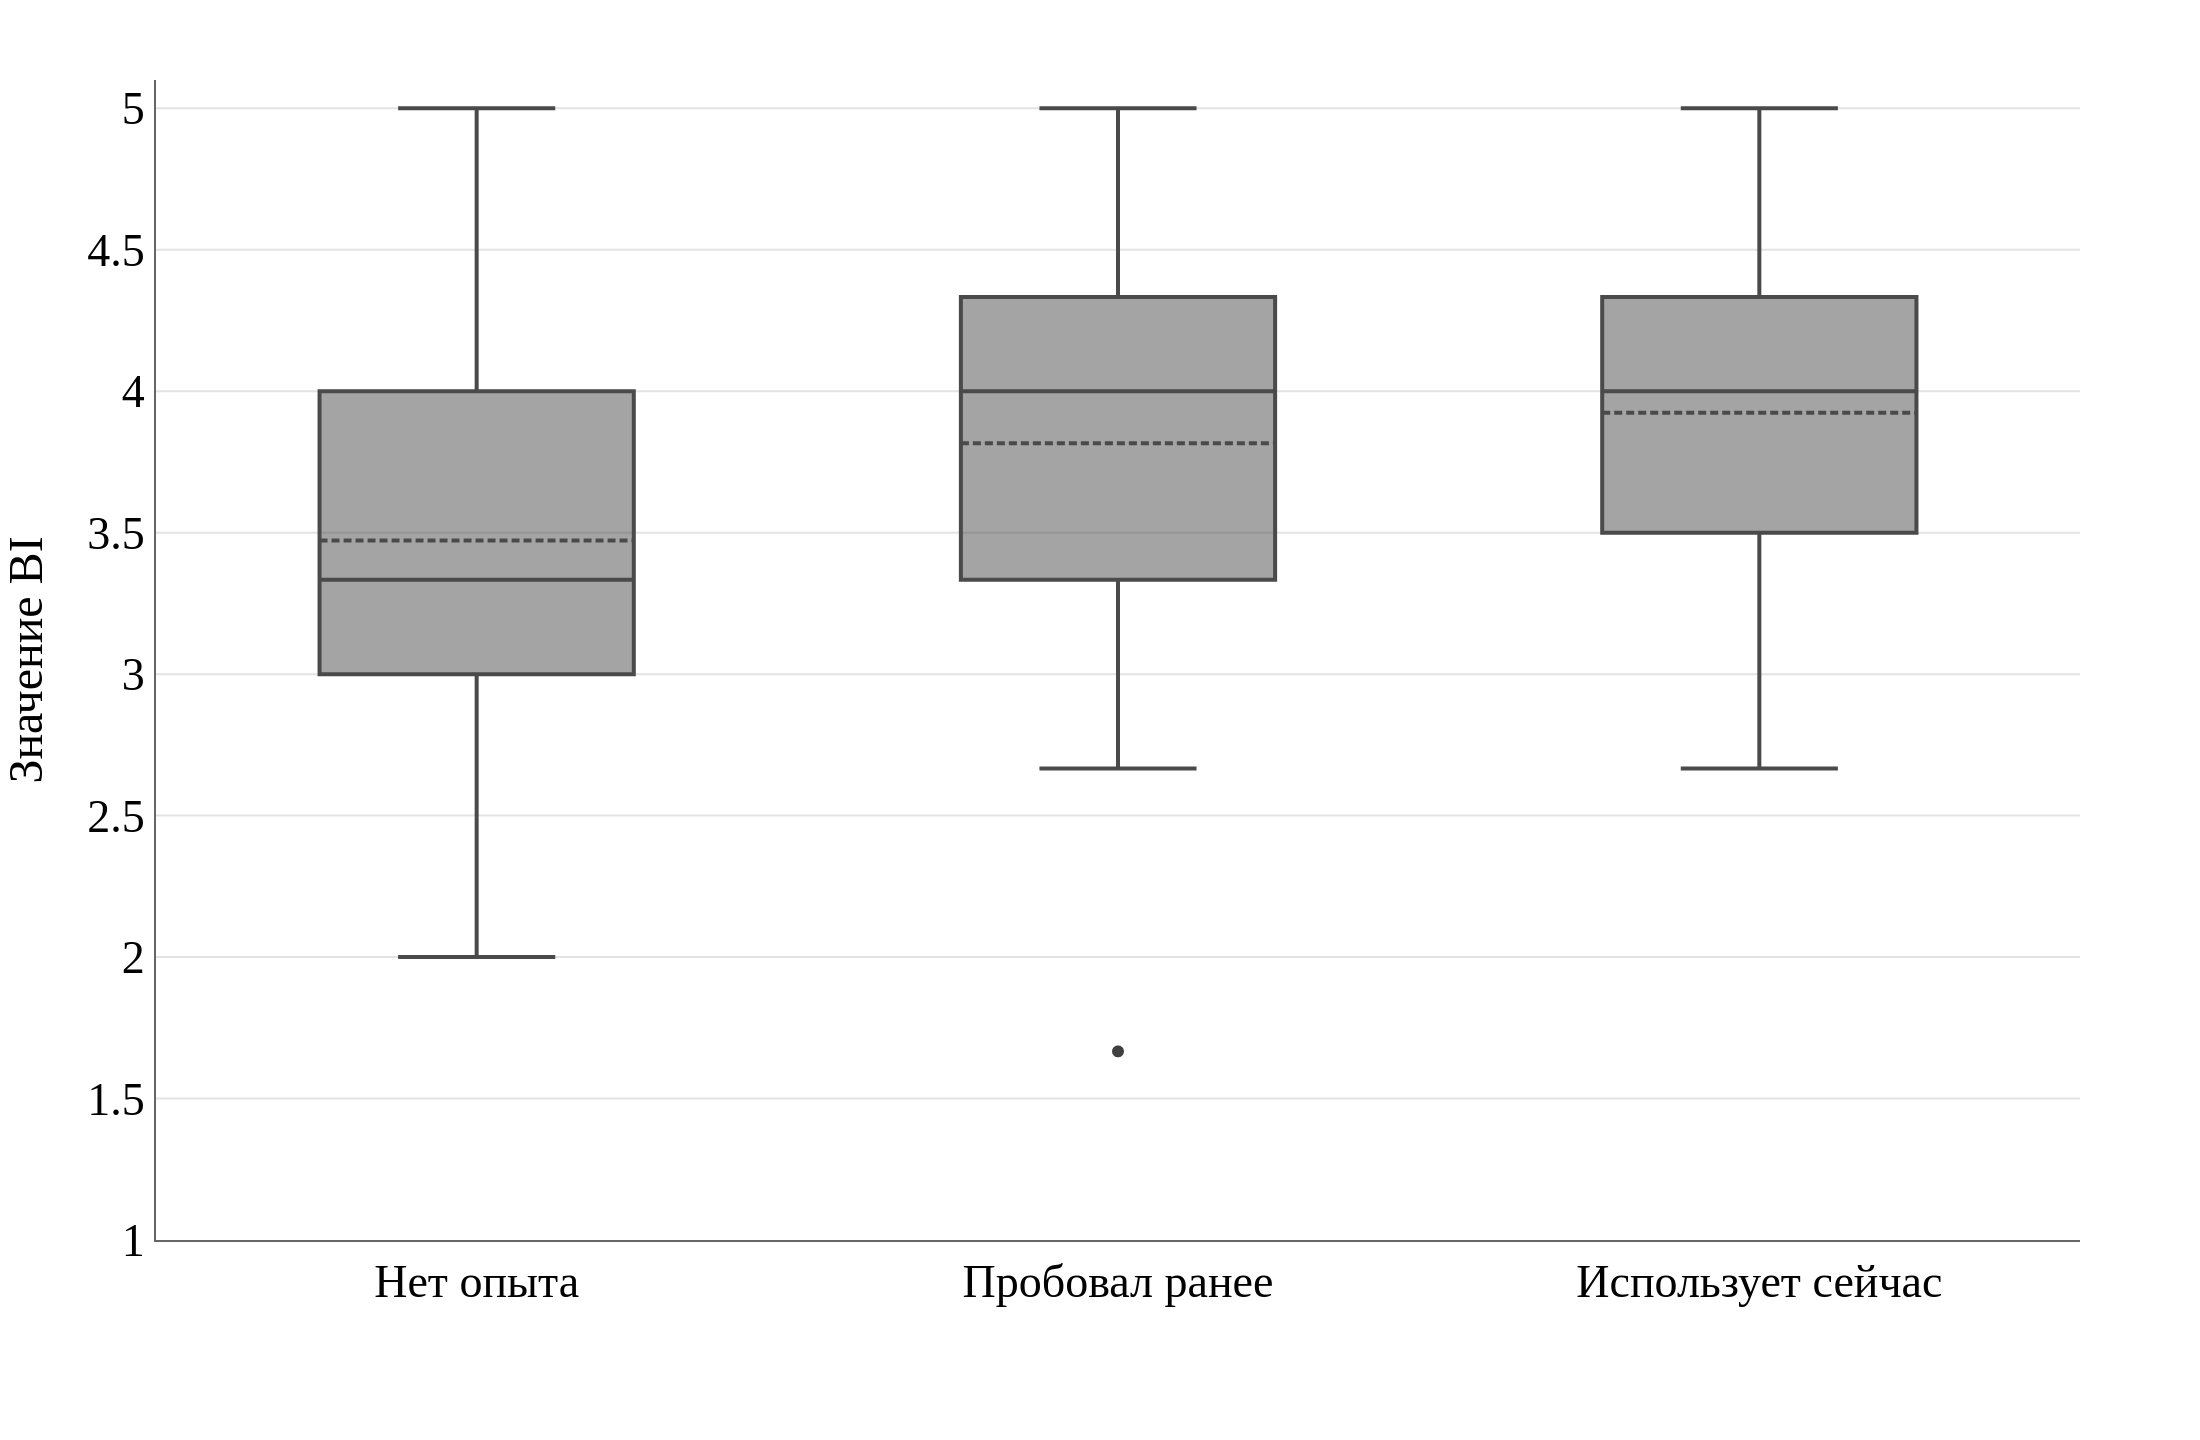

In [3]:
exp_short = {
    'No': 'Нет опыта',
    'Yes, tried in the past but no longer use them': 'Пробовал ранее',
    'Yes, currently use them': 'Использует сейчас'
}

da['exp_ru'] = da[exp_col].map(exp_short)

fig = go.Figure()

for name in ['Нет опыта', 'Пробовал ранее', 'Использует сейчас']:
    fig.add_trace(go.Box(
        y=da.loc[da['exp_ru'] == name, 'BI'],
        name=name,
        marker_color=PRIMARY,
        line_color=PRIMARY_DARK,
        boxmean=True
    ))

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1
    ),
    yaxis=dict(
        title=dict(text='Значение BI', font=dict(size=24)),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[1, 5.1]
    ),
    margin=dict(l=70, r=60, t=40, b=100),
    width=1100,
    height=720
)

fig.show()

In [4]:
male_bi = da.loc[da['What is your gender?'] == 'Male', 'BI']
female_bi = da.loc[da['What is your gender?'] == 'Female', 'BI']
U_gender, p_gender = stats.mannwhitneyu(male_bi, female_bi, alternative='two-sided')

print('BI по полу:')
print(f'Мужчины: M = {male_bi.mean():.2f}, SD = {male_bi.std():.2f}, n = {len(male_bi)}')
print(f'Женщины: M = {female_bi.mean():.2f}, SD = {female_bi.std():.2f}, n = {len(female_bi)}')
print(f'Mann-Whitney U = {U_gender:.0f}, p = {p_gender:.4f}\n')

age_groups = [g.values for _, g in da.groupby('What is your age?')['BI'] if len(g) >= 5]
if len(age_groups) >= 2:
    H_age, p_age = stats.kruskal(*age_groups)
    print(f'BI по возрастным группам (только группы с n >= 5): H = {H_age:.2f}, p = {p_age:.4f}')

BI по полу:
Мужчины: M = 3.71, SD = 0.68, n = 98
Женщины: M = 3.71, SD = 0.69, n = 66
Mann-Whitney U = 3262, p = 0.9244

BI по возрастным группам (только группы с n >= 5): H = 1.52, p = 0.6778


In [5]:
print('Вывод:')
print('Наиболее заметные различия в BI наблюдаются между группами, различающимися по опыту использования онлайн-фитнеса.')

if p_gender >= 0.05:
    print('Статистически значимых различий BI по полу не выявлено.')

if 'p_age' in locals() and p_age >= 0.05:
    print('Статистически значимых различий BI по возрастным группам также не выявлено.')


Вывод:
Наиболее заметные различия в BI наблюдаются между группами, различающимися по опыту использования онлайн-фитнеса.
Статистически значимых различий BI по полу не выявлено.
Статистически значимых различий BI по возрастным группам также не выявлено.
